In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


warnings.filterwarnings('ignore')

In [167]:
df=pd.read_csv('salary_prediction_dataset.csv')
df

,Age,Experience (Years),Education Level,City,Salary
0,42,26,Bachelor,Mumbai,103987.30
1,43,24,Master,Bangalore,113956.62
2,44,26,Master,Kolkata,96754.89
3,45,29,High School,Bangalore,80428.01
4,46,26,Master,Kolkata,103601.09
...,...,...,...,...,...
995,77,60,Bachelor,Mumbai,189344.45
996,78,56,Bachelor,Kolkata,134490.99
997,79,63,Bachelor,Kolkata,142930.57
998,80,61,High School,Bangalore,130227.26


In [168]:
df.shape

(1000, 5)

In [169]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 1000 non-null   int64  
 1   Experience (Years)  1000 non-null   int64  
 2   Education Level     1000 non-null   object 
 3   City                1000 non-null   object 
 4   Salary              1000 non-null   float64
dtypes: float64(1), int64(2), object(2)
memory usage: 39.2+ KB


In [170]:
df.describe()

,Age,Experience (Years),Salary
count,1000.000000,1000.000000,1000.000000
mean,50.880000,31.840000,102663.844740
std,17.267999,17.393762,46288.166794
min,21.000000,-1.000000,11837.400000
25%,36.000000,17.000000,68024.060000
50%,51.000000,32.000000,96388.700000
75%,66.000000,47.000000,132834.712500
max,80.000000,64.000000,282659.650000


In [171]:
df.columns

Index(['Age', 'Experience (Years)', 'Education Level', 'City', 'Salary'], dtype='object')

In [172]:
df.isnull().sum()

Age                   0
Experience (Years)    0
Education Level       0
City                  0
Salary                0
dtype: int64

In [173]:
df.duplicated().sum()

np.int64(0)

In [174]:
df.select_dtypes('object')

,Education Level,City
0,Bachelor,Mumbai
1,Master,Bangalore
2,Master,Kolkata
3,High School,Bangalore
4,Master,Kolkata
...,...,...
995,Bachelor,Mumbai
996,Bachelor,Kolkata
997,Bachelor,Kolkata
998,High School,Bangalore


In [175]:
df.select_dtypes('object').nunique()

Education Level    4
City               5
dtype: int64

In [176]:
df1=pd.get_dummies(df.select_dtypes('object'),drop_first=True).astype(int)
df1

,Education Level_High School,Education Level_Master,Education Level_PhD,City_Chennai,City_Delhi,City_Kolkata,City_Mumbai
0,0,0,0,0,0,0,1
1,0,1,0,0,0,0,0
2,0,1,0,0,0,1,0
3,1,0,0,0,0,0,0
4,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...
995,0,0,0,0,0,0,1
996,0,0,0,0,0,1,0
997,0,0,0,0,0,1,0
998,1,0,0,0,0,0,0


In [177]:
df.drop(df.select_dtypes('object'),axis=1,inplace=True)
df

,Age,Experience (Years),Salary
0,42,26,103987.30
1,43,24,113956.62
2,44,26,96754.89
3,45,29,80428.01
4,46,26,103601.09
...,...,...,...
995,77,60,189344.45
996,78,56,134490.99
997,79,63,142930.57
998,80,61,130227.26


In [178]:
df=pd.concat([df,df1],axis=1)
df

,Age,Experience (Years),Salary,Education Level_High School,Education Level_Master,Education Level_PhD,City_Chennai,City_Delhi,City_Kolkata,City_Mumbai
0,42,26,103987.30,0,0,0,0,0,0,1
1,43,24,113956.62,0,1,0,0,0,0,0
2,44,26,96754.89,0,1,0,0,0,1,0
3,45,29,80428.01,1,0,0,0,0,0,0
4,46,26,103601.09,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...
995,77,60,189344.45,0,0,0,0,0,0,1
996,78,56,134490.99,0,0,0,0,0,1,0
997,79,63,142930.57,0,0,0,0,0,1,0
998,80,61,130227.26,1,0,0,0,0,0,0


In [179]:
x=df.drop('Salary',axis=1)
y=df[['Salary']]
x

,Age,Experience (Years),Education Level_High School,Education Level_Master,Education Level_PhD,City_Chennai,City_Delhi,City_Kolkata,City_Mumbai
0,42,26,0,0,0,0,0,0,1
1,43,24,0,1,0,0,0,0,0
2,44,26,0,1,0,0,0,1,0
3,45,29,1,0,0,0,0,0,0
4,46,26,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...
995,77,60,0,0,0,0,0,0,1
996,78,56,0,0,0,0,0,1,0
997,79,63,0,0,0,0,0,1,0
998,80,61,1,0,0,0,0,0,0


In [180]:
y

,Salary
0,103987.30
1,113956.62
2,96754.89
3,80428.01
4,103601.09
...,...
995,189344.45
996,134490.99
997,142930.57
998,130227.26


In [181]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=45)
x_train

,Age,Experience (Years),Education Level_High School,Education Level_Master,Education Level_PhD,City_Chennai,City_Delhi,City_Kolkata,City_Mumbai
791,53,32,0,1,0,0,1,0,0
143,65,44,0,1,0,0,0,0,0
880,22,5,0,0,0,0,0,0,1
339,21,-1,0,0,0,0,0,0,1
992,74,53,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...
544,46,25,0,1,0,1,0,0,0
892,34,16,1,0,0,0,0,1,0
643,25,7,1,0,0,0,1,0,0
414,36,19,0,0,0,0,0,0,1


In [182]:
x_test

,Age,Experience (Years),Education Level_High School,Education Level_Master,Education Level_PhD,City_Chennai,City_Delhi,City_Kolkata,City_Mumbai
726,48,30,0,1,0,0,0,0,1
243,45,23,0,0,0,1,0,0,0
342,24,4,0,0,0,1,0,0,0
976,58,37,0,0,0,0,1,0,0
919,61,42,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...
458,80,62,0,0,0,0,0,1,0
169,31,15,0,1,0,0,0,0,1
297,39,20,0,0,0,0,1,0,0
10,52,36,0,0,0,0,0,1,0


In [183]:
y_train

,Salary
791,128209.37
143,168163.04
880,42437.82
339,25048.38
992,150233.42
...,...
544,93325.10
892,45443.27
643,24373.67
414,85416.18


In [184]:
y_test

,Salary
726,133726.10
243,74127.96
342,44142.36
976,113209.97
919,81098.79
...,...
458,140404.42
169,93418.55
297,72902.07
10,98840.34


<function matplotlib.pyplot.plot(*args: 'float | ArrayLike | str', scalex: 'bool' = True, scaley: 'bool' = True, data=None, **kwargs) -> 'list[Line2D]'>

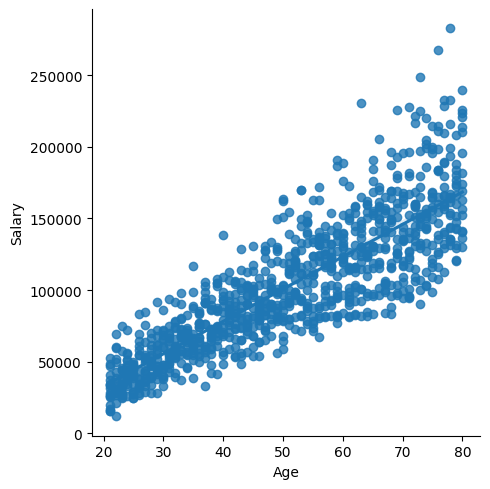

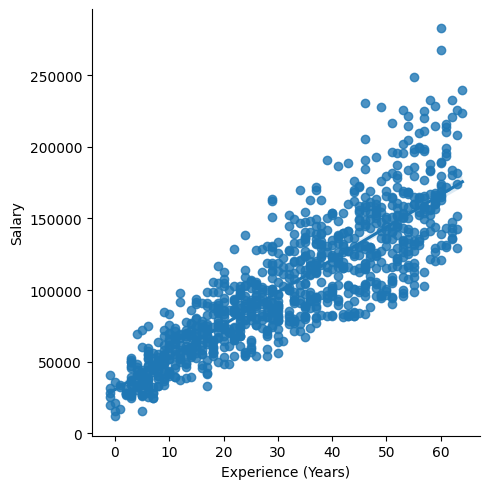

In [ ]:
sns.lmplot(x='Age',y='Salary',data=df)
plt.plot
sns.lmplot(x='Experience (Years)',y='Salary',data=df)
plt.plot


In [ ]:
lr=LinearRegression()

In [187]:
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [188]:
lr.coef_

array([[-7.62484708e+00,  2.27032225e+03, -2.37007413e+04,
         2.34026375e+04,  5.42443187e+04, -8.52385314e+03,
        -3.91144633e+03, -1.80649941e+04,  9.28295151e+03]])

In [189]:
lr.intercept_

array([33531.12642051])

In [191]:
y_pred=lr.predict(x_test)
y_pred

array([[133960.39028316],
       [ 76881.56694146],
       [ 33905.56595313],
       [113179.36226749],
       [ 86653.80984126],
       [ 68755.43223546],
       [ 97923.08690549],
       [158376.79773313],
       [125602.39223172],
       [142018.60427568],
       [144849.5010812 ],
       [101282.42615046],
       [139784.86713466],
       [ 64230.03742678],
       [105813.90668124],
       [ 56072.68802111],
       [ 67326.71539118],
       [156162.9881029 ],
       [172047.61901575],
       [198479.87133313],
       [ 92743.32331308],
       [129254.66838677],
       [ 24364.42497203],
       [  7459.40068931],
       [144770.11391878],
       [109055.46914125],
       [150212.53879175],
       [190310.91319358],
       [ 45226.67782191],
       [ 86825.53138336],
       [152356.74409977],
       [ -1599.01377513],
       [136589.62458472],
       [156339.95274016],
       [  5211.95297912],
       [116161.21047738],
       [ 79919.92777254],
       [177348.67725117],
       [1442

In [192]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))

7196.1576582261805
93817562.55451053


In [193]:
result=pd.DataFrame(columns=['Actual','Predicted'])
result['Actual']=y_test
result['Predicted']=y_pred
result.reset_index()
result

,Actual,Predicted
726,133726.10,133960.390283
243,74127.96,76881.566941
342,44142.36,33905.565953
976,113209.97,113179.362267
919,81098.79,86653.809841
...,...,...
458,140404.42,155616.124118
169,93418.55,100035.178912
297,72902.07,74728.756088
10,98840.34,96801.241299


In [194]:
print(r2_score(y_test,y_pred))

0.9546326641144189
